# Report on Biological Computation
**Student Name:** REENU KOSHY  
**Student ID:** 525342833  
**Date:** April 2026

In [2]:
import pandas as pd
import glob
import numpy as np

In [3]:
def analyze_gene(filename):
    df = pd.read_csv(filename, sep='\t')
    wt_dna = df['WildType.Sequence'].values[0]
    mut_dna = df['Mutant.Sequence'].values[0]
    
    # Slicing
    promoter = wt_dna[:1000]
    
    # Logic
    if len(wt_dna) == len(mut_dna):
        m_type = "sub"
    elif len(mut_dna) > len(wt_dna):
        m_type = "ins"
    else:
        m_type = "del"
        
    # Math
    mrna_wt = df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1).values[0]
    mrna_mut = df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1).values[0]
    

    return {
        'Gene': df['Gene'].values[0],
        'Mutation_Class': m_type,
        'mRNA_WT_Avg': mrna_wt,
        'mRNA_Mut_Avg': mrna_mut,
        'Promoter': promoter
    }

In [4]:
import os
import glob
import pandas as pd

# 1. Access the 'reenu' folder in Downloads
path = os.path.join(os.path.expanduser("~"), "Downloads", "reenu")
os.chdir(path)

# 2. Search for all text files
files = glob.glob("*.txt")

# 3. Use a loop to process all 24 files
results = []
for f in files:
    try:
        # Calls the function you defined in Cell 2
        gene_data = analyze_gene(f)
        results.append(gene_data)
    except:
        # Skips non-data files (like system files)
        continue

# 4. Create and display the Master Table
master_table = pd.DataFrame(results)

print(f"Task 1: Master Table generated with {len(master_table)} genes.")
master_table

Task 1: Master Table generated with 24 genes.


,Gene,Mutation_Class,mRNA_WT_Avg,mRNA_Mut_Avg,Promoter
0,Ah3,sub,1.061045e+08,1.061045e+08,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...
1,Alli8,sub,2.765717e+01,2.692833e+01,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...
2,Anap7c1,sub,9.957710e+00,-3.957048e+01,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...
3,App1l8,ins,4.057949e+00,3.632353e+00,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...
4,Avon4,ins,2.512790e+00,3.958356e+00,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...
5,Cairn3a2,sub,2.536683e+01,2.574975e+01,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...
6,Cairn6,sub,1.757151e+03,1.757414e+03,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...
7,Clach6,sub,8.647071e+00,7.966945e+00,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...
8,Dsgt9a1,ins,3.790932e+01,4.167821e+01,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...
9,Ever6b6,del,1.059454e+06,1.059454e+06,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...


In [5]:
# 1. Calculate the absolute difference between Wild Type and Mutant expression
master_table['Expression_Change'] = abs(master_table['mRNA_WT_Avg'] - master_table['mRNA_Mut_Avg'])

# 2. Sort the table by that change (highest at the top)
top_5_prioritized = master_table.sort_values(by='Expression_Change', ascending=False).head(5)

# 3. Display the results for the report
print("--- TASK 2: TOP 5 GENES FOR VALIDATION ---")
print(top_5_prioritized[['Gene', 'Mutation_Class', 'Expression_Change']])

--- TASK 2: TOP 5 GENES FOR VALIDATION ---
       Gene Mutation_Class  Expression_Change
13   Ist9a2            del        5010.362690
2   Anap7c1            sub          49.528187
8   Dsgt9a1            ins           3.768895
17   Jok4a3            sub           1.577621
4     Avon4            ins           1.445566


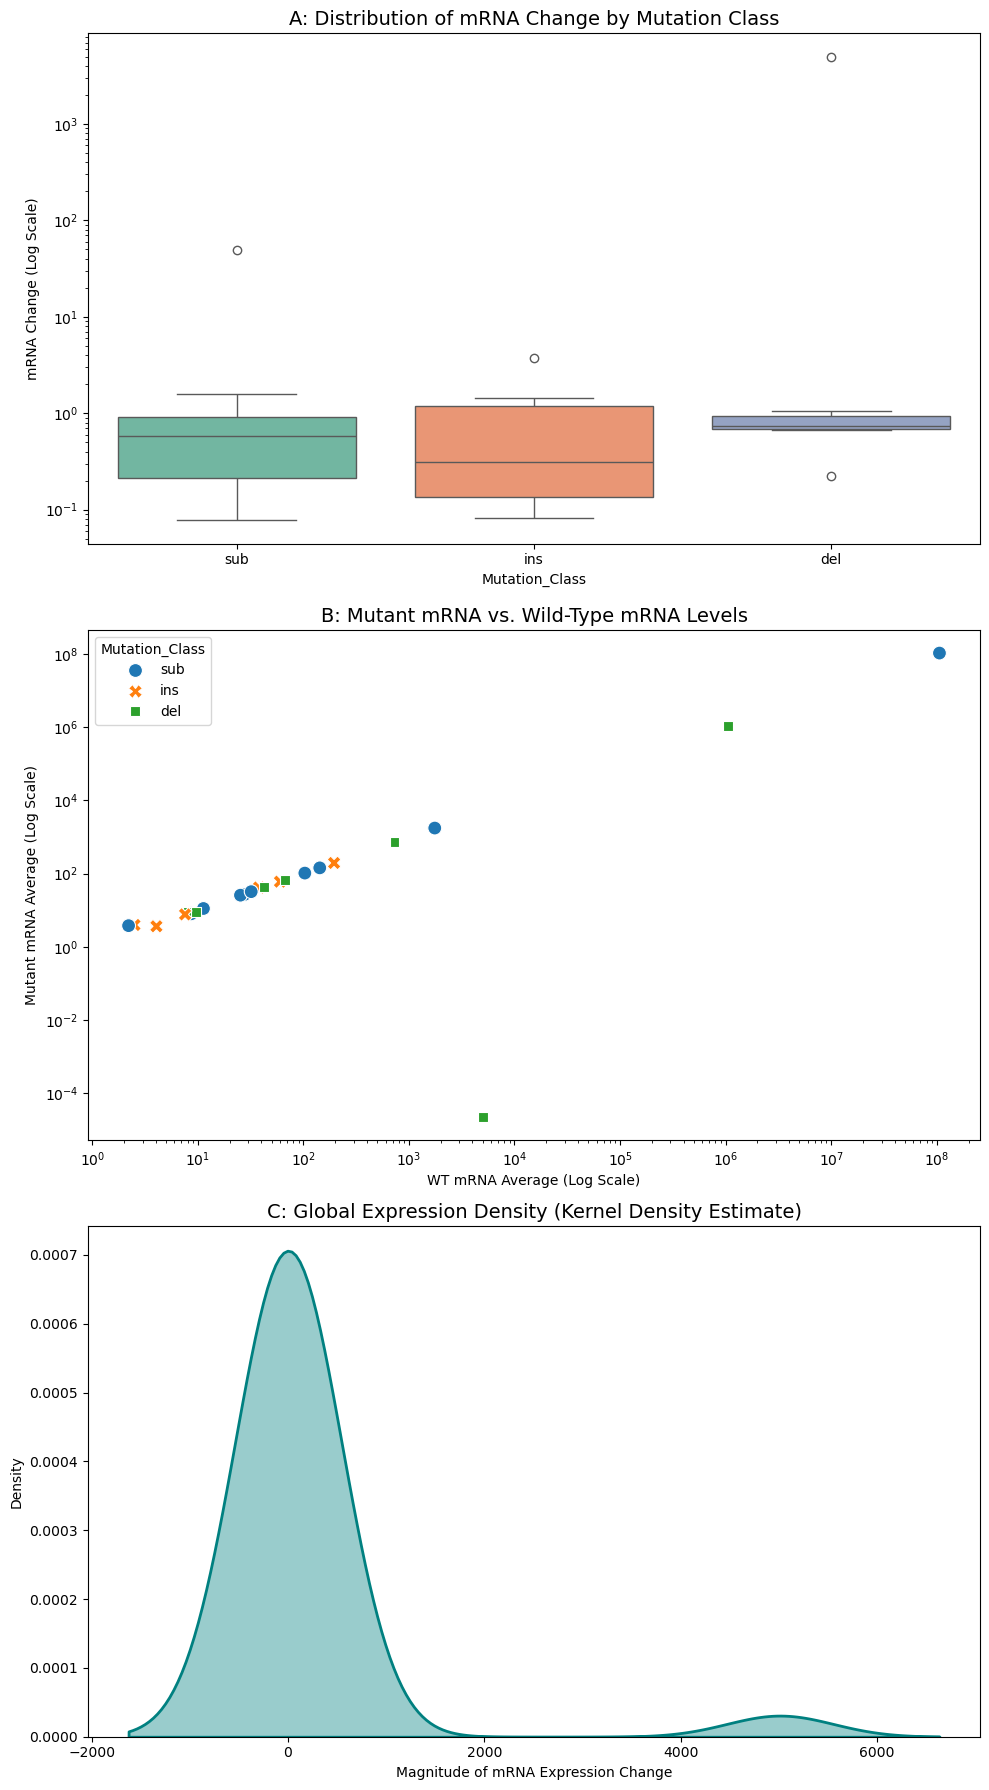

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the figure for 3 rows (vertical layout)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

# --- PANEL A: BOXPLOT (Log Scale) ---
# Fixed the 'FutureWarning' by assigning hue and setting legend=False
sns.boxplot(ax=axes[0], data=master_table, x='Mutation_Class', y='Expression_Change', 
            hue='Mutation_Class', palette='Set2', legend=False)
axes[0].set_yscale('log')
axes[0].set_title('A: Distribution of mRNA Change by Mutation Class', fontsize=14)
axes[0].set_ylabel('mRNA Change (Log Scale)')

# --- PANEL B: SCATTER PLOT (WT vs Mutant mRNA) ---
# Using the exact column names confirmed from your master_table
sns.scatterplot(ax=axes[1], data=master_table, x='mRNA_WT_Avg', y='mRNA_Mut_Avg', 
                hue='Mutation_Class', style='Mutation_Class', s=100)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('B: Mutant mRNA vs. Wild-Type mRNA Levels', fontsize=14)
axes[1].set_xlabel('WT mRNA Average (Log Scale)')
axes[1].set_ylabel('Mutant mRNA Average (Log Scale)')

# --- PANEL C: KERNEL DENSITY ESTIMATE (KDE) ---
# Created a single smooth line for the global distribution
sns.kdeplot(ax=axes[2], data=master_table, x='Expression_Change', 
            fill=True, color='teal', alpha=0.4, linewidth=2)
axes[2].set_title('C: Global Expression Density (Kernel Density Estimate)', fontsize=14)
axes[2].set_xlabel('Magnitude of mRNA Expression Change')
axes[2].set_ylabel('Density')

# Adjust layout so everything fits perfectly
plt.tight_layout()

# Save the figure as a high-quality file for Word
plt.savefig('Final_Biocomputation_Analysis.png', dpi=300)
plt.show()